In [59]:
import importlib
import src.liquidity
importlib.reload(src.liquidity)

<module 'src.liquidity' from '/Users/aditya/Desktop/market-risk-engine/src/liquidity.py'>

In [49]:
from src. liquidity import build_cashflow_ladder

ladder_stress = build_cashflow_ladder(
    inflows,
    outflows,
    times,
    initial_buffer=100,
    inflow_haircut=0.2,
    outflow_stress=0.3   # 30% deposit run
)

ladder_stress

,time,inflows,outflows,effective_inflows,stressed_outflows,net,cumulative_net,available_liquidity
0,1,100,80,80.0,104.0,-24.0,-24.0,76.0
1,2,50,60,40.0,78.0,-38.0,-62.0,38.0
2,3,30,100,24.0,130.0,-106.0,-168.0,-68.0
3,4,20,30,16.0,39.0,-23.0,-191.0,-91.0
4,5,10,20,8.0,26.0,-18.0,-209.0,-109.0


In [50]:
compute_survival_horizon(ladder_stress)

3.0

In [41]:
from src.liquidity import build_cashflow_ladder

times = np.array([1, 2, 3, 4, 5])
inflows = np.array([100, 50, 30, 20, 10])
outflows = np.array([80, 60, 100, 30, 20])

ladder = build_cashflow_ladder(inflows, outflows, times)

ladder

,time,inflows,outflows,net,cumulative_net,available_liquidity
0,1,100,80,20,20,20.0
1,2,50,60,-10,10,10.0
2,3,30,100,-70,-60,-60.0
3,4,20,30,-10,-70,-70.0
4,5,10,20,-10,-80,-80.0


In [53]:
from src.liquidity import simulate_liquidity_survival

survival_dist = simulate_liquidity_survival(
    inflows,
    outflows,
    times,
    initial_buffer=150,
    inflow_haircut=0.2,
    sims=5000,
    seed=42
)

np.mean(survival_dist), np.min(survival_dist), np.max(survival_dist)

(3.5888, 3.0, 5.0)

In [54]:
np.mean(survival_dist <= 3)

0.5768

In [55]:
np.mean(survival_dist == 5)

0.1656

In [56]:
np.percentile(survival_dist, 5)

3.0

In [42]:
from src.liquidity import compute_survival_horizon

horizon = compute_survival_horizon(ladder)

horizon

3.0

In [43]:
from src.liquidity import build_cashflow_ladder, compute_survival_horizon

times = np.array([1, 2, 3, 4, 5])
inflows = np.array([100, 50, 30, 20, 10])
outflows = np.array([80, 60, 100, 30, 20])

# No buffer
ladder_no_buffer = build_cashflow_ladder(inflows, outflows, times)

# With buffer
ladder_with_buffer = build_cashflow_ladder(inflows, outflows, times, initial_buffer=100)

ladder_no_buffer, ladder_with_buffer

(   time  inflows  outflows  net  cumulative_net  available_liquidity
 0     1      100        80   20              20                 20.0
 1     2       50        60  -10              10                 10.0
 2     3       30       100  -70             -60                -60.0
 3     4       20        30  -10             -70                -70.0
 4     5       10        20  -10             -80                -80.0,
    time  inflows  outflows  net  cumulative_net  available_liquidity
 0     1      100        80   20              20                  120
 1     2       50        60  -10              10                  110
 2     3       30       100  -70             -60                   40
 3     4       20        30  -10             -70                   30
 4     5       10        20  -10             -80                   20)

In [57]:
sims = 5000
np.random.seed(42)

systemic_factors = np.random.normal(size=sims)

In [60]:
from src.liquidity import simulate_liquidity_with_systemic_factor

survival_dist_sys = simulate_liquidity_with_systemic_factor(
    inflows,
    outflows,
    times,
    initial_buffer=150,
    inflow_haircut=0.2,
    systemic_factors=systemic_factors
)

In [61]:
np.corrcoef(credit_losses, survival_dist_sys)

NameError: name 'credit_losses' is not defined

In [64]:
# --------------------------------------
# MARKET RISK (Systemic-driven)
# --------------------------------------

beta = 0.02     # systemic sensitivity
sigma = 0.01    # idiosyncratic volatility

epsilon_market = np.random.normal(size=sims)

market_returns = beta * systemic_factors + sigma * epsilon_market

# Assume portfolio value = 1000
portfolio_value = 1000

market_pnl = portfolio_value * market_returns

print("Mean Market PnL:", np.mean(market_pnl))

Mean Market PnL: 0.21238614603791248


In [66]:
liquidity_penalty = np.where(survival_dist_sys <= 3, 500, 0)
enterprise_loss = (
    credit_losses
    - market_pnl      # negative pnl adds to loss
    + liquidity_penalty
)

np.percentile(enterprise_loss, 99)

2777.4924691055076

In [67]:
np.random.seed(42)

# ---------------------------
# Independent factors
# ---------------------------

F_credit = np.random.normal(size=sims)
F_market = np.random.normal(size=sims)
F_liquidity = np.random.normal(size=sims)

# ---------------------------
# CREDIT (independent)
# ---------------------------

epsilon = np.random.normal(size=(sims, n_obligors))

Z_credit = (
    np.sqrt(rho) * F_credit[:, None] +
    np.sqrt(1 - rho) * epsilon
)

U_credit = norm.cdf(Z_credit)
defaults_credit = U_credit < pd
credit_losses_indep = (defaults_credit * exposure * lgd).sum(axis=1)

# ---------------------------
# MARKET (independent)
# ---------------------------

epsilon_market = np.random.normal(size=sims)
market_returns_indep = beta * F_market + sigma * epsilon_market
market_pnl_indep = portfolio_value * market_returns_indep

# ---------------------------
# LIQUIDITY (independent)
# ---------------------------

survival_indep = simulate_liquidity_with_systemic_factor(
    inflows,
    outflows,
    times,
    initial_buffer=150,
    inflow_haircut=0.2,
    systemic_factors=F_liquidity
)

liquidity_penalty_indep = np.where(survival_indep <= 3, 500, 0)

# ---------------------------
# Enterprise Loss (independent)
# ---------------------------

enterprise_loss_indep = (
    credit_losses_indep
    - market_pnl_indep
    + liquidity_penalty_indep
)

enterprise_var_99_indep = np.percentile(enterprise_loss_indep, 99)

enterprise_var_99_indep

2437.4667752178607

In [62]:
import numpy as np
from scipy.stats import norm
from src.credit import simulate_correlated_credit_losses
from src.liquidity import simulate_liquidity_with_systemic_factor

# --------------------------------------
# Simulation settings
# --------------------------------------

sims = 5000
np.random.seed(42)

# --------------------------------------
# Systemic factor
# --------------------------------------

systemic_factors = np.random.normal(size=sims)

# --------------------------------------
# CREDIT PORTFOLIO SETUP
# --------------------------------------

n_obligors = 200

pd = np.random.uniform(0.01, 0.03, n_obligors)
exposure = np.random.uniform(50, 200, n_obligors)
lgd = np.random.uniform(0.4, 0.6, n_obligors)

rho = 0.3  # asset correlation

# Modify credit model logic inline to use SAME systemic_factors

epsilon = np.random.normal(size=(sims, n_obligors))

Z = (
    np.sqrt(rho) * systemic_factors[:, None] +
    np.sqrt(1 - rho) * epsilon
)

U = norm.cdf(Z)

defaults = U < pd

credit_losses = (defaults * exposure * lgd).sum(axis=1)

# --------------------------------------
# LIQUIDITY SETUP
# --------------------------------------

times = np.array([1, 2, 3, 4, 5])
inflows = np.array([100, 50, 30, 20, 10])
outflows = np.array([80, 60, 100, 30, 20])

initial_buffer = 150
inflow_haircut = 0.2

survival_dist_sys = simulate_liquidity_with_systemic_factor(
    inflows,
    outflows,
    times,
    initial_buffer,
    inflow_haircut,
    systemic_factors
)

# --------------------------------------
# Correlation
# --------------------------------------

correlation = np.corrcoef(credit_losses, survival_dist_sys)[0,1]

print("Mean Credit Loss:", np.mean(credit_losses))
print("Mean Survival Time:", np.mean(survival_dist_sys))
print("Correlation (Credit Loss vs Survival Time):", correlation)

Mean Credit Loss: 245.4950073181506
Mean Survival Time: 3.9592
Correlation (Credit Loss vs Survival Time): -0.5010411709819734


In [63]:
credit_var_99 = np.percentile(credit_losses, 99)

joint_tail_prob = np.mean(
    (credit_losses > credit_var_99) &
    (survival_dist_sys <= 3)
)

credit_var_99, joint_tail_prob

(2236.6111963481785, 0.01)

In [28]:
import sys
import os

# Add project root to Python path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

print("Project root added:", project_root)

Project root added: /Users/aditya/Desktop/market-risk-engine


In [17]:
import importlib
import src.irrbb
importlib.reload(src.irrbb)

<module 'src.irrbb' from '/Users/aditya/Desktop/market-risk-engine/src/irrbb.py'>

In [12]:
import numpy as np
from src.irrbb import (
    present_value,
    run_irrbb_scenario,
    compute_dv01,
    compute_dv01_analytical,
    compute_key_rate_dv01,
    portfolio_present_value,
    portfolio_key_rate_dv01
)

# --------------------------
# Yield Curve Setup
# --------------------------

rate_times = np.array([1, 2, 3])
rates = np.array([0.05, 0.05, 0.05])

# --------------------------
# Single Instrument Test
# --------------------------

cashflows = np.array([100, 100, 1100])
times = np.array([1, 2, 3])

base_pv = present_value(cashflows, times, rates, rate_times)

print("Base PV:", base_pv)

# --------------------------
# Parallel Shock Test (+100bps)
# --------------------------

shock = 0.01
shock_vector = np.array([shock, shock, shock])

scenario_result = run_irrbb_scenario(
    cashflows, times,
    rates, rate_times,
    shock_vector
)

print("Parallel Shock Result:", scenario_result)

# --------------------------
# DV01 Tests
# --------------------------

dv01_num = compute_dv01(cashflows, times, rates, rate_times)
dv01_ana = compute_dv01_analytical(cashflows, times, rates, rate_times)

print("Numerical DV01:", dv01_num)
print("Analytical DV01:", dv01_ana)

# --------------------------
# Key Rate DV01
# --------------------------

krd = compute_key_rate_dv01(cashflows, times, rates, rate_times)

print("Key Rate DV01:", krd)
print("Sum KRD:", np.sum(krd))

# --------------------------
# Portfolio Test
# --------------------------

bond = {
    "cashflows": np.array([100, 100, 1100]),
    "times": np.array([1, 2, 3])
}

deposit = {
    "cashflows": np.array([-500, -500]),
    "times": np.array([1, 2])
}

instruments = [bond, deposit]

portfolio_pv = portfolio_present_value(instruments, rates, rate_times)
portfolio_krd = portfolio_key_rate_dv01(instruments, rates, rate_times)

print("Portfolio PV:", portfolio_pv)
print("Portfolio KRD:", portfolio_krd)
print("Portfolio Parallel DV01:", np.sum(portfolio_krd))

Base PV: 1132.385458321231
Parallel Shock Result: {'base_pv': 1132.385458321231, 'shocked_pv': 1101.6657295825398, 'delta_pv': -30.719728738691174}
Numerical DV01: -0.3115977888883208
Analytical DV01: -0.3116426748259954
Key Rate DV01: [-0.00951182 -0.01809494 -0.28399103]
Sum KRD: -0.3115977888883208
Portfolio PV: 204.35203705289427
Portfolio KRD: [ 0.03804727  0.07237976 -0.28399103]
Portfolio Parallel DV01: -0.17356400162509544


In [5]:
from src.irrbb import compute_ear

ear_result = compute_ear(
    instruments,
    rates,
    rate_times,
    horizon=1,  # 1-year horizon
    shock_vector=np.array([0.01, 0.01, 0.01])
)

ear_result

{'base_income': -380.4917698002856,
 'shocked_income': -376.7058134336995,
 'delta_income': 3.785956366586106}

In [13]:
from src.irrbb import compute_convexity

conv = compute_convexity(cashflows, times, rates, rate_times)

conv

8978.066944109742

In [15]:
# --- Recompute DV01 ---
dv01 = compute_dv01(cashflows, times, rates, rate_times)

# --- Compute Convexity ---
conv = compute_convexity(cashflows, times, rates, rate_times)

print("DV01:", dv01)
print("Convexity:", conv)

# --- 100bps shock comparison ---
shock = 0.01

# Actual shock result
scenario = run_irrbb_scenario(
    cashflows,
    times,
    rates,
    rate_times,
    shock_vector=np.array([shock, shock, shock])
)

actual_delta = scenario["delta_pv"]

# Linear estimate
linear_estimate = dv01 * 100  # dv01 is per 1bp

# Quadratic-adjusted estimate
quadratic_estimate = linear_estimate + 0.5 * conv * (shock ** 2)

print("Actual ΔPV:", actual_delta)
print("Linear Estimate:", linear_estimate)
print("Quadratic Estimate:", quadratic_estimate)

DV01: -0.3115977888883208
Convexity: 8978.066944109742
Actual ΔPV: -30.719728738691174
Linear Estimate: -31.15977888883208
Quadratic Estimate: -30.710875541626592


In [8]:
from src.simulation import simulate_normal_returns
from src.simulation import simulate_multivariate_returns
from src.portfolio import compute_portfolio_returns
from src.var import compute_var, compute_es
from src.backtest import kupiec_test

In [18]:
from src.irrbb import generate_basel_shock_scenarios

scenarios = generate_basel_shock_scenarios(rate_times, shock_size=0.02)

results = {}

for name, shock in scenarios.items():
    scenario_result = run_irrbb_scenario(
        cashflows,
        times,
        rates,
        rate_times,
        shock
    )
    results[name] = scenario_result["delta_pv"]

results

{'parallel_up': -60.567582223549834,
 'parallel_down': 64.15985219039567,
 'steepener': -53.21449259557858,
 'flattener': 56.66196927131068}

In [25]:
min(results.values())

-60.567582223549834

In [ ]:
from src.stress import apply_volatility_stress, apply_correlation_stress

In [ ]:
import numpy as np
# --- Base setup ---
mu = np.array([0.0005, 0.0003])
sigma = np.array([0.01, 0.015])

corr = np.array([[1.0, 0.3],
                 [0.3, 1.0]])

weights = np.array([0.6, 0.4])

D = np.diag(sigma)
cov = D @ corr @ D

# --- Base simulation ---
sim_returns = simulate_multivariate_returns(mu, cov, 100000, seed=42)
portfolio_returns = compute_portfolio_returns(sim_returns, weights)
var_99_port = compute_var(portfolio_returns)

# --- Stress ---
stressed_sigma = apply_volatility_stress(sigma, 1.5)
stressed_corr = apply_correlation_stress(corr, 0.2)

stressed_D = np.diag(stressed_sigma)
stressed_cov = stressed_D @ stressed_corr @ stressed_D

stressed_returns = simulate_multivariate_returns(mu, stressed_cov, 100000, seed=42)
stressed_portfolio_returns = compute_portfolio_returns(stressed_returns, weights)
stressed_var = compute_var(stressed_portfolio_returns)

var_99_port, stressed_var

In [ ]:
import importlib
import src.stress
importlib.reload(src.stress)

In [ ]:
from src.stress import run_stress_scenario

In [ ]:
result = run_stress_scenario(
    mu=mu,
    sigma=sigma,
    corr=corr,
    weights=weights,
    vol_shock=1.5,
    corr_shock=0.2,
    sims=100000,
    alpha=0.99,
    seed=42
)

result

In [ ]:
from src.credit import simulate_credit_losses

In [ ]:
pd = np.array([0.02, 0.01, 0.03])
exposure = np.array([100, 200, 150])
lgd = np.array([0.6, 0.5, 0.4])

losses = simulate_credit_losses(pd, exposure, lgd, sims=100000, seed=42)

losses[:10]

In [ ]:
n = 100

pd = np.random.uniform(0.005, 0.03, n)
exposure = np.random.uniform(50, 200, n)
lgd = np.random.uniform(0.3, 0.7, n)

losses = simulate_credit_losses(pd, exposure, lgd, sims=100000, seed=42)

np.mean(losses), np.percentile(losses, 99)

In [ ]:
from src.credit import compute_credit_var, compute_credit_es

credit_var = compute_credit_var(losses, 0.99)
credit_es = compute_credit_es(losses, 0.99)

credit_var, credit_es

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(losses, bins=50, density=True, alpha=0.6)
plt.axvline(credit_var, linestyle='--')
plt.axvline(credit_es, linestyle=':')

plt.title("Credit Portfolio Loss Distribution")
plt.xlabel("Loss")
plt.ylabel("Density")

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(losses[losses > credit_var * 0.8], bins=50, density=True)
plt.axvline(credit_var, linestyle='--')
plt.axvline(credit_es, linestyle='--')

plt.title("Right Tail of Credit Loss Distribution")
plt.show()

In [ ]:
sorted_losses = np.sort(losses)
cdf = np.arange(len(sorted_losses)) / len(sorted_losses)

plt.figure(figsize=(8,5))
plt.plot(sorted_losses, cdf)
plt.axvline(credit_var, linestyle='--')
plt.title("Credit Loss CDF")
plt.xlabel("Loss")
plt.ylabel("Cumulative Probability")
plt.show()

In [ ]:
from src.credit import simulate_correlated_credit_losses

In [ ]:
rho = 0.2

corr_losses = simulate_correlated_credit_losses(
    pd, exposure, lgd,
    rho=rho,
    sims=100000,
    seed=42
)

np.mean(corr_losses), np.percentile(corr_losses, 99)

In [ ]:
returns = simulate_normal_returns(0.0005, 0.01, 100000, seed=42)

var_99 = compute_var(returns)
es_99 = compute_es(returns)

var_99, es_99

In [ ]:
import matplotlib.pyplot as plt
rhos = np.linspace(0, 0.8, 10)
vars_corr = []

for r in rhos:
    losses_corr = simulate_correlated_credit_losses(
        pd, exposure, lgd,
        rho=r,
        sims=50000,
        seed=42
    )
    vars_corr.append(np.percentile(losses_corr, 99))

plt.figure(figsize=(8,5))
plt.plot(rhos, vars_corr)
plt.xlabel("Correlation (rho)")
plt.ylabel("99% Credit VaR")
plt.title("VaR vs Correlation")
plt.show()

In [ ]:
import importlib
import src.credit
importlib.reload(src.credit)

In [ ]:
from src.credit import simulate_sector_credit_losses
n = 200

pd = np.random.uniform(0.01, 0.03, n)
exposure = np.random.uniform(50, 200, n)
lgd = np.random.uniform(0.4, 0.6, n)

# Assign 4 sectors
sector_ids = np.random.randint(0, 4, n)

losses_sector = simulate_sector_credit_losses(
    pd, exposure, lgd,
    sector_ids=sector_ids,
    rho=0.3,
    sims=100000,
    seed=42
)

np.mean(losses_sector), np.percentile(losses_sector, 99)

In [ ]:
np.bincount(sector_ids)

In [ ]:
losses_indep = simulate_credit_losses(pd, exposure, lgd, sims=100000, seed=42)
np.percentile(losses_indep, 99)

In [ ]:
losses_single = simulate_correlated_credit_losses(
    pd, exposure, lgd,
    rho=0.3,
    sims=100000,
    seed=42
)
np.percentile(losses_single, 99)

In [ ]:
losses_sector = simulate_sector_credit_losses(
    pd, exposure, lgd,
    sector_ids=sector_ids,
    rho=0.3,
    sims=100000,
    seed=42
)
np.percentile(losses_sector, 99)

In [ ]:
from src.irrbb import present_value

cashflows = np.array([100, 100, 1100])
times = np.array([1, 2, 3])
rates = np.array([0.05, 0.05, 0.05])
rate_times = np.array([1, 2, 3])

base_pv = present_value(cashflows, times, rates, rate_times)
base_pv

In [ ]:
from src.irrbb import *

In [ ]:
shock = 0.01  # +100 bps

shocked_rates = rates + shock

shocked_pv = present_value(cashflows, times, shocked_rates, rate_times)

delta_pv = shocked_pv - base_pv

base_pv, shocked_pv, delta_pv

In [ ]:
from src.irrbb import apply_key_rate_shock

In [ ]:
shock_vector = np.array([0.01, 0.02, 0.00])

shocked_rates = apply_key_rate_shock(rates, shock_vector)

pv_shocked = present_value(cashflows, times, shocked_rates, rate_times)

delta_pv = pv_shocked - base_pv

delta_pv

In [ ]:
from src.irrbb import run_irrbb_scenario

result = run_irrbb_scenario(
    cashflows, times, rates, rate_times,
    shock_vector=np.array([0.01, 0.02, 0.00])
)

result

In [ ]:
from src.irrbb import compute_dv01

dv01 = compute_dv01(cashflows, times, rates, rate_times)

dv01

In [ ]:
from src.irrbb import compute_dv01_analytical

dv01_analytical = compute_dv01_analytical(cashflows, times, rates, rate_times)

dv01, dv01_analytical

In [ ]:
from src.irrbb import compute_key_rate_dv01

krd = compute_key_rate_dv01(cashflows, times, rates, rate_times)

krd

In [ ]:
krd.sum(), dv01

In [ ]:
from src.irrbb import portfolio_present_value, portfolio_key_rate_dv01

# Asset: 3Y bond
bond = {
    "cashflows": np.array([100, 100, 1100]),
    "times": np.array([1, 2, 3])
}

# Liability: 2Y deposit
deposit = {
    "cashflows": np.array([-500, -500]),
    "times": np.array([1, 2])
}

instruments = [bond, deposit]

rates = np.array([0.05, 0.05, 0.05])

portfolio_pv = portfolio_present_value(instruments, rates, rate_times)

portfolio_krd = portfolio_key_rate_dv01(instruments, rates, rate_times)

portfolio_pv, portfolio_krd, np.sum(portfolio_krd)

In [ ]:
rate_times = np.array([1, 2, 3])
rates = np.array([0.05, 0.05, 0.05])

bond = {
    "cashflows": np.array([100, 100, 1100]),
    "times": np.array([1, 2, 3])
}

deposit = {
    "cashflows": np.array([-500, -500]),
    "times": np.array([1, 2])
}

instruments = [bond, deposit]

portfolio_pv = portfolio_present_value(instruments, rates, rate_times)
portfolio_pv

In [ ]:
from backtest import count_var_breaches, breach_ratio

In [ ]:
num_breaches, breaches = count_var_breaches(returns, var_99)
ratio = breach_ratio(num_breaches, len(returns))

num_breaches, ratio

In [ ]:
from backtest import kupiec_test

In [ ]:
lr_stat, p_value = kupiec_test(num_breaches, len(returns), 0.99)

lr_stat, p_value

In [ ]:
from simulation import simulate_multivariate_returns

In [ ]:
import numpy as np

mu = np.array([0.0005, 0.0003])
sigma = np.array([0.01, 0.015])

corr = np.array([[1.0, 0.3],
                 [0.3, 1.0]])

D = np.diag(sigma)
cov = D @ corr @ D

sim_returns = simulate_multivariate_returns(mu, cov, 100000, seed=42)

sim_returns.shape

In [ ]:
weights = np.array([0.6, 0.4])

portfolio_returns = sim_returns @ weights

portfolio_returns.shape

In [ ]:
var_99_port = compute_var(portfolio_returns)
es_99_port = compute_es(portfolio_returns)

var_99_port, es_99_port

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.hist(portfolio_returns, bins=50, density=True, alpha=0.6)
plt.axvline(var_99_port, linestyle='--')
plt.axvline(es_99_port, linestyle='--')

plt.title("Portfolio Return Distribution (99% VaR & ES)")
plt.show()

In [ ]:
portfolio_variance = weights @ cov @ weights
portfolio_vol_analytical = np.sqrt(portfolio_variance)

portfolio_vol_analytical

In [ ]:
portfolio_vol_simulated = np.std(portfolio_returns)

portfolio_vol_simulated

In [ ]:
import sys
import importlib

sys.path.append("../src")

import simulation
import var

importlib.reload(simulation)
importlib.reload(var)

from simulation import simulate_normal_returns
from var import compute_var, compute_es

In [ ]:
returns = simulate_normal_returns(0.0005, 0.01, 100000, seed=42)
type(returns)

In [ ]:
returns = simulate_normal_returns(0.0005, 0.01, 100000, seed=42)

var_99 = compute_var(returns)
es_99 = compute_es(returns)

var_99, es_99

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

In [ ]:
# simulation layer
#     ↓
# risk metric layer (VaR, ES)
#     ↓
# aggregation layer
#     ↓
# validation layer
#     ↓
# stress layer

In [ ]:
# Single asset returns simulation

def simulate_normal_returns(mu, sigma, sims, seed = None):
    """ Simulate ND distn."""
    if seed is not None:
        np.random.seed(seed)
        
    z = np.random.normal(size = sims)
    returns = mu + sigma*z
    return returns

In [ ]:
# Test
returns = simulate_normal_returns(mu=0.0005, sigma=0.01, sims=100000)
returns[:5]

In [ ]:
returns.mean()

In [ ]:
def compute_var_es(returns, alpha = 0.99):
    """
    Compute Value at Risk and Expected Shortfall
    """
    var = np.percentile(returns, 5)
    es = returns[returns < var].mean()
    return var, es

var_99, es_99 = compute_var_es(returns)
var_99, es_99

In [ ]:
plt.figure(figsize = (8,5))
plt.hist(returns, bins = 50, alpha = 0.6, density = True)
plt.axvline(var_99, linestyle = '--')
plt.axvline(es_99, linestyle = '--')
plt.title("Simulated Return Distribution with 99% VaR and ES")
plt.xlabel("Return")
plt.ylabel("Density")
plt.show()

In [ ]:
import sys
sys.path.append("../src")

from simulation import simulate_normal_returns
from var import compute_var, compute_es

In [ ]:
import numpy as np

def compute_var(returns, alpha = 0.99):
    """
    calculate Value at Risk corresponding to
    alpha confidence level
    """   
    return np.percentile(returns, 100*(1-alpha))

def compute_es(returns, alpha = 0.99):
    """
    calculate Value at Risk corresponding to
    alpha confidence level
    """
    x = compute_var(returns, alpha) 
    return returns[returns < x].mean()

In [ ]:
import var
print(var.__file__)

In [ ]:
import sys, os.path as osp

SRC = osp.abspath("../src")
if SRC not in sys.path:
    sys.path.append(SRC)

from simulation import simulate_normal_returns
from var import compute_var, compute_es

In [ ]:
import sys, os.path as osp

print(sys.path[0])
print(osp.abspath("../src"))

import var
print("Using var from:", var.__file__)
print(dir(var))

In [ ]:
def compute_var_es(returns, alpha=0.99):
    """
    Compute VaR and ES of returns
    """
    var = np.percentile(var, 100*(1-alpha))
    es = returns[returns<var].mean()
    
    return -var, -es

In [ ]:
def simulate_one_factor_credit(pd, exposure, lgd, rho, sims):
    """
    Insert explanation
    """
    

In [1]:
import numpy as np

# portfolio in foreign currency

usd_exposure = 10000
eur_exposure = 8000

# Current FX rates

usd_inr = 93.50
eur_inr = 90

# Convert to INR

portfolio_value = usd_exposure*usd_inr + eur_exposure*eur_inr

portfolio_value

1655000.0

In [2]:
sims = 1000

# FX volatility assumption

usd_vol = 0.01
eur_vol = 0.012

usd_returns = np.random.normal(0,usd_vol, sims)
eur_returns = np.random.normal(0,eur_vol, sims)

In [3]:
usd_pnl = usd_returns*usd_inr*usd_exposure
eur_pnl = eur_returns*eur_inr*eur_exposure

In [5]:
total_pnl = usd_pnl + eur_pnl

In [8]:
-np.percentile(total_pnl,1)

30032.74036072646

In [20]:
import sys

sys.path.append("/Users/aditya/Desktop/market-risk-engine/src")

In [16]:
cd

/Users/aditya


In [23]:
from fx import simulate_fx_var

exposures = [10000, 8000]
rates = [83, 90]
vols = [0.01, 0.012]

simulate_fx_var(exposures, rates, vols)

19961.65172851507

In [24]:
import os
print(os.listdir("/Users/aditya/Desktop/market-risk-engine/src"))

['simulation.py', 'liquidity.py', '.DS_Store', 'irrbb.py', '__init__.py', '__pycache__', 'stress.py', 'var.py', '.ipynb_checkpoints', 'fx.py', 'backtest.py', 'portfolio.py', 'credit.py']


In [26]:
import importlib
import fx

importlib.reload(fx)

from fx import simulate_correlated_fx_var

In [27]:
from fx import simulate_correlated_fx_var

exposures = [10000, 8000]
rates = [83, 90]
vols = [0.01, 0.012]

corr_matrix = np.array([
    [1.0, 0.5],
    [0.5, 1.0]
])

simulate_correlated_fx_var(exposures, rates, vols, corr_matrix)

33166.240118886715

In [28]:
def compute_component_var(returns, weights, alpha=0.99):
    """
    Compute component VaR using simulation
    """

    portfolio_returns = returns @ weights

    var_threshold = np.percentile(portfolio_returns, 100*(1-alpha))

    # Select tail scenarios
    tail_mask = portfolio_returns <= var_threshold

    tail_returns = returns[tail_mask]

    # Expected contribution in tail
    component_var = (tail_returns.mean(axis=0)) * weights

    return component_var, var_threshold

In [29]:
# Simulate correlated returns
mean = [0, 0]
cov = [[0.0001, 0.00005],
       [0.00005, 0.0002]]

returns = np.random.multivariate_normal(mean, cov, size=10000)

weights = np.array([0.6, 0.4])

comp_var, var_threshold = compute_component_var(returns, weights)

comp_var, var_threshold

(array([-0.01339721, -0.01259757]), -0.022964514714313364)

In [31]:
-0.01339721 -0.01259757

-0.025994780000000002

In [33]:
def calculate_lcr(hqla, outflows, inflows):
    """
    calculate LCR = hqla / net outflow CF (next 30 days)
    """
    total_outflow = np.sum(outflows)
    total_inflow = np.sum(inflows)
    outflow = total_outflow - min(total_inflow , 0.75*total_outflow)
    lcr = hqla/outflow if outflow > 0 else np.inf
    
    return lcr

In [34]:
from liquidity import compute_lcr

hqla = 500

inflows = np.array([50, 40, 30])
outflows = np.array([100, 120, 80])

compute_lcr(hqla, inflows, outflows)

2.7777777777777777

In [33]:
import numpy as np
from scipy.stats import norm
def simulate_correlated_credit_losses(pd, lgd, ead, rho, sims = 10000, seed = None):
    """
    Simulate 1 factor gaussian copula
    """
    
    if seed is not None:
        np.random.seed(seed)
        
    pd = np.array(pd)
    lgd = np.array(lgd)
    ead = np.array(ead)
    n = len(pd)
    
    F = np.random.normal(size = sims)
    E = np.random.normal(size = (sims,n))
    
    Z = F[:,None]*np.sqrt(rho) + E*np.sqrt(1-rho)
    
    U = norm.cdf(Z)
    
    loss_matrix = U < pd
    
    loss = (loss_matrix*lgd*ead).sum(axis = 1)
    return loss

In [35]:
pd = np.array([0.02, 0.03, 0.01])
lgd = np.array([0.5, 0.4, 0.6])
ead = np.array([100, 150, 200])

losses = simulate_correlated_credit_losses(pd, lgd, ead, rho=0.2, sims=5000, seed=42)

print(losses[:10])
print(losses.shape)

[ 0.  0.  0.  0.  0. 60.  0.  0.  0.  0.]
(5000,)


In [36]:
pd = np.array([0.0, 0.0, 0.0])

losses = simulate_correlated_credit_losses(pd, lgd, ead, rho=0.5, sims=5000)

print(np.unique(losses))

[0.]


In [37]:
pd = np.array([1.0, 1.0, 1.0])

losses = simulate_correlated_credit_losses(pd, lgd, ead, rho=0.5, sims=1000)

print(np.unique(losses))

[230.]


In [38]:
pd = np.random.uniform(0.01, 0.03, 100)
lgd = np.random.uniform(0.4, 0.6, 100)
ead = np.random.uniform(50, 200, 100)

loss_low_corr = simulate_correlated_credit_losses(pd, lgd, ead, rho=0.0)
loss_high_corr = simulate_correlated_credit_losses(pd, lgd, ead, rho=0.8)

print(np.percentile(loss_low_corr, 99))
print(np.percentile(loss_high_corr, 99))

407.3585083099883
3688.6019649884356


In [39]:
expected_loss = np.sum(pd * lgd * ead)
simulated_mean = np.mean(loss_low_corr)

print(expected_loss, simulated_mean)

133.45370361311723 135.07990220351456


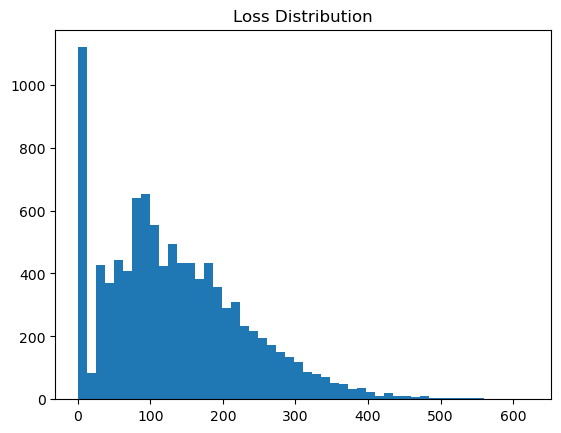

In [40]:
import matplotlib.pyplot as plt

plt.hist(loss_low_corr, bins=50)
plt.title("Loss Distribution")
plt.show()

In [2]:
from enterprise import simulate_enterprise_var

import numpy as np

credit_params = {
    "pd": np.random.uniform(0.01, 0.03, 100),
    "exposure": np.random.uniform(50, 200, 100),
    "lgd": np.random.uniform(0.4, 0.6, 100),
    "rho": 0.3
}

fx_params = {
    "exposures": [10000, 8000],
    "rates": [83, 90],
    "vols": [0.01, 0.012]
}

liquidity_params = {
    "inflows": np.array([100, 50, 30]),
    "outflows": np.array([80, 60, 100]),
    "buffer": 150,
    "haircut": 0.2
}

var, losses = simulate_enterprise_var(
    credit_params,
    fx_params,
    liquidity_params
)

print(var)

27599.6728848885


In [42]:
cd

/Users/aditya


In [43]:
import sys

sys.path.append("/Users/aditya/Desktop/market-risk-engine/src")

In [47]:
ead = credit_params["exposure"]

array([114.91159779, 112.6801193 , 158.2981562 , 149.767472  ,
        69.08230891, 185.81023237, 164.86735609, 188.14120965,
       195.55714073,  84.75855558,  78.89763993,  62.85578502,
       117.56172693, 146.74742839, 125.30724206,  74.94417158,
       193.08870721, 146.91306325, 177.12161409, 170.30733593,
       175.19771052, 179.23407368, 151.5790994 ,  98.79307186,
        65.61068301, 168.1856305 , 112.42799101, 101.55476342,
        69.78297644,  75.93589374,  65.12595088,  72.97112955,
        97.73798258,  74.80455503, 187.99830817,  64.41953253,
        53.74601954,  64.24411125,  71.95095705, 124.74246778,
       159.17608123, 170.47203849,  94.70452087, 143.37630224,
       132.02312607, 119.24252529, 157.52802519,  90.02100266,
       183.24681608, 139.21580942, 153.62653078, 173.28476758,
       146.84608292, 131.45733218,  52.51860078, 126.97396347,
       129.1487825 , 100.59434531, 109.66812589,  85.94708342,
       171.69960805, 101.18607703,  71.27522988,  75.08

In [49]:
pd = np.random.uniform(0.01, 0.03, 100)
ead = np.random.uniform(50, 200, 100)
lgd = np.random.uniform(0.4, 0.6, 100)

losses = simulate_correlated_credit_losses(pd, ead, lgd, rho=0.3, sims=5000)

print(losses.shape)
print(np.percentile(losses, 99))

(5000,)
1174.0962372427744


In [53]:
import importlib
import credit
importlib.reload(credit)

<module 'credit' from '/Users/aditya/Desktop/market-risk-engine/src/credit.py'>

In [1]:
import sys
sys.path.append("/Users/aditya/Desktop/market-risk-engine/src")

from enterprise import simulate_enterprise_var

In [3]:
from enterprise import simulate_enterprise_var

var, losses = simulate_enterprise_var(
    credit_params,
    fx_params,
    liquidity_params
)

print(var)

28430.231899008388
